In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt

from notebook_utils import bootstrap_mean_and_ci

In [2]:
def prepend_ones(arr):
    ones = np.ones((arr.shape[0], 1))
    return np.hstack((ones, arr))

def load_vision_method_soft(model, method):
    with open(f"../scripts/_cache/soft_rates_{method}_{model}_imagenet_2_per_class.json") as f:
        return prepend_ones(np.array(json.load(f)["soft_stability_rates"]))

def load_vision_method_hard(model, method):
    with open(f"../scripts/_cache/hard_radii_{method}_{model}_imagenet_2_per_class.json") as f:
        l2r = json.load(f)["lambda_to_radii"]
        return {lambda_: np.array(l2r[lambda_]) for lambda_ in ["0.125", "0.250", "0.375", "0.500"]}

methods = ["lime", "shap", "intgrad", "mfaba", "random"]
vit_soft_rates = {m: load_vision_method_soft("vit", m) for m in methods}
resnet50_soft_rates = {m: load_vision_method_soft("resnet50", m) for m in methods}
resnet18_soft_rates = {m: load_vision_method_soft("resnet18", m) for m in methods}

vit_hard_radii = {m: load_vision_method_hard("vit", m) for m in methods}
resnet50_hard_radii = {m: load_vision_method_hard("resnet50", m) for m in methods}
resnet18_hard_radii = {m: load_vision_method_hard("resnet18", m) for m in methods}

In [3]:
def right_padded(lists):
    max_len = max(len(ls) for ls in lists)
    padded_array = np.array([ls + [0] * (max_len - len(ls)) for ls in lists])
    return padded_array

def load_roberta_task_method_soft(task, method):
    with open(f"../scripts/_cache/soft_rates_{method}_roberta_tweeteval_{task}.json") as f:
        return prepend_ones(right_padded(json.load(f)["soft_stability_rates"]))

def load_roberta_task_method_hard(task, method):
    with open(f"../scripts/_cache/hard_radii_{method}_roberta_tweeteval_{task}.json") as f:
        l2r = json.load(f)["lambda_to_radii"]
        return {lambda_: np.array(l2r[lambda_]) for lambda_ in ["0.125", "0.250", "0.375", "0.500"]}

In [4]:
roberta_emoji_soft_rates = {m: load_roberta_task_method_soft("emoji", m) for m in methods}
roberta_emotion_soft_rates = {m: load_roberta_task_method_soft("emotion", m) for m in methods}
roberta_hate_soft_rates = {m: load_roberta_task_method_soft("hate", m) for m in methods}
roberta_irony_soft_rates = {m: load_roberta_task_method_soft("irony", m) for m in methods}
roberta_offensive_soft_rates = {m: load_roberta_task_method_soft("offensive", m) for m in methods}
roberta_sentiment_soft_rates = {m: load_roberta_task_method_soft("sentiment", m) for m in methods}

roberta_all_soft_rates = {
    m: np.vstack([
        roberta_emoji_soft_rates[m],
        roberta_emotion_soft_rates[m],
        roberta_hate_soft_rates[m],
        roberta_irony_soft_rates[m],
        roberta_offensive_soft_rates[m],
        roberta_sentiment_soft_rates[m]
    ])
    for m in methods
}

roberta_emoji_hard_radii = {m: load_roberta_task_method_hard("emoji", m) for m in methods}
roberta_emotion_hard_radii = {m: load_roberta_task_method_hard("emotion", m) for m in methods}
roberta_hate_hard_radii = {m: load_roberta_task_method_hard("hate", m) for m in methods}
roberta_irony_hard_radii = {m: load_roberta_task_method_hard("irony", m) for m in methods}
roberta_offensive_hard_radii = {m: load_roberta_task_method_hard("offensive", m) for m in methods}
roberta_sentiment_hard_radii = {m: load_roberta_task_method_hard("sentiment", m) for m in methods}

roberta_all_hard_radii = {
    m : {
        lambda_: np.concatenate([
            roberta_emoji_hard_radii[m][lambda_],
            roberta_emotion_hard_radii[m][lambda_],
            roberta_hate_hard_radii[m][lambda_],
            roberta_irony_hard_radii[m][lambda_],
            roberta_offensive_hard_radii[m][lambda_],
            roberta_sentiment_hard_radii[m][lambda_],
        ])
        for lambda_ in ["0.125", "0.250", "0.375", "0.500"]
    }
    for m in methods
}

In [5]:
def plot_soft_rates(model_rates, radii, model, legend_loc=None, fs=14, plot_ci=True, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))
    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["lime"])
    ax.plot(radii, mean, label="LIME")
    ax.fill_between(radii, lb, ub, alpha=0.2)
    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["shap"])
    ax.plot(radii, mean, label="SHAP")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    mean, lb, ub = bootstrap_mean_and_ci(model_rates["intgrad"])
    ax.plot(radii, mean, label="IntGrad")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    mean, lb, ub = bootstrap_mean_and_ci(model_rates["mfaba"])
    ax.plot(radii, mean, label="MFABA")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    mean, lb, ub = bootstrap_mean_and_ci(model_rates["random"])
    ax.plot(radii, mean,label="Random")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    # ax.set_ylim(0.0, 1.05)
    ax.set_xlabel(f"({model}) Pert Radius", fontsize=fs+2)
    ax.set_ylabel("Stability Rate", fontsize=fs+2)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(loc=legend_loc, title_fontsize=fs, fontsize=fs)
    # ax.legend(loc
    return fig

In [6]:
# image_radii = [0, 1, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 147]
image_radii = list(range(0,21)) + [30, 40, 50, 60, 70, 80, 90, 100]
text_radii = list(range(21))

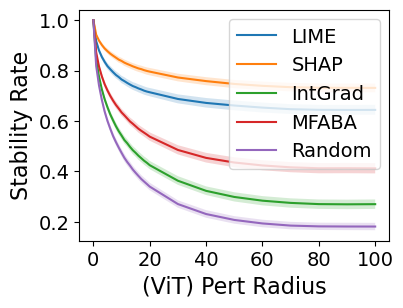

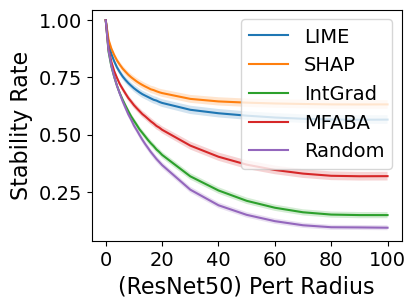

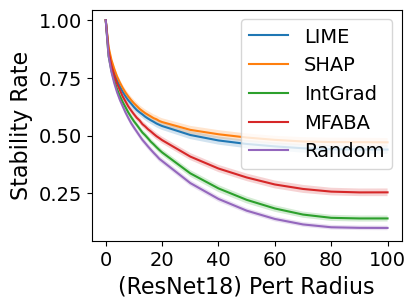

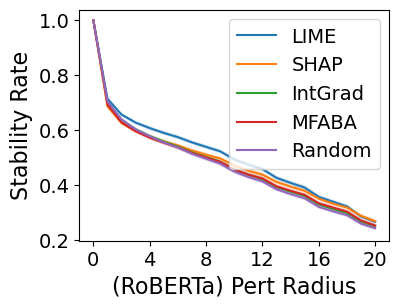

In [7]:
fig = plot_soft_rates(vit_soft_rates, image_radii, "ViT", legend_loc="upper right", xticks=[0, 20, 40, 60, 80, 100])
fig.savefig("_dump/soft_vs_method_vit_imagenet_2_per_class.pdf", bbox_inches="tight")

fig = plot_soft_rates(resnet50_soft_rates, image_radii, "ResNet50", legend_loc="upper right", xticks=[0, 20, 40, 60, 80, 100])
fig.savefig("_dump/soft_vs_method_resnet50_imagenet_2_per_class.pdf", bbox_inches="tight")

fig = plot_soft_rates(resnet18_soft_rates, image_radii, "ResNet18", legend_loc="upper right", xticks=[0, 20, 40, 60, 80, 100])
fig.savefig("_dump/soft_vs_method_resnet18_imagenet_2_per_class.pdf", bbox_inches="tight")

fig = plot_soft_rates(roberta_all_soft_rates, text_radii, "RoBERTa", xticks=[0, 4, 8, 12, 16, 20])
fig.savefig("_dump/soft_vs_method_roberta_tweeteval_all.pdf", bbox_inches="tight")

In [8]:
def plot_soft_hard_radii_by_method(soft_dict, hard_dict, model, method, legend_loc=None, fs=14, xticks=None, est_hard=False):
    fig, ax = plt.subplots(figsize=(4,3))
    r_max = 4

    soft_radii = list(range(0, r_max+1))
    soft_mean, soft_lb, soft_ub = bootstrap_mean_and_ci(soft_dict[method.lower()][:,:r_max+1])
    ax.plot(soft_radii, soft_mean, label="SCA")
    ax.fill_between(soft_radii, soft_lb, soft_ub, alpha=0.2)

    if est_hard:
        est_hards = (soft_dict[method.lower()] > 0.999).astype(float)[:,:r_max+1]
        est_hards_mean, est_hard_lb, est_hard_ub = bootstrap_mean_and_ci(est_hards)
        ax.plot(soft_radii, est_hards_mean, label="SCA-hard")
        ax.fill_between(soft_radii, est_hard_lb, est_hard_ub, alpha=0.2)

    # Hard radii next
    r_ticks = np.linspace(0.0, r_max+0.1, num=1000)
    cert_rs = np.array([(hard_dict[method.lower()]["0.125"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.125$")
    
    cert_rs = np.array([(hard_dict[method.lower()]["0.250"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.250$")
    
    cert_rs = np.array([(hard_dict[method.lower()]["0.375"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.375$")
    
    cert_rs = np.array([(hard_dict[method.lower()]["0.500"] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="$\lambda = 0.500$")

    
    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel(f"({model} {method}) Pert Radius", fontsize=fs+1)
    ax.set_ylabel("Stability Rate", fontsize=fs+2)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xlim(0.0, xticks[-1] + 0.1)
    else:
        ax.set_xticks([0, 1.0, 2.0, 3.0, 4.0])
        ax.set_xlim(0.0, r_max+0.1)

    ax.legend(loc=legend_loc, title_fontsize=fs, fontsize=fs)
    return fig

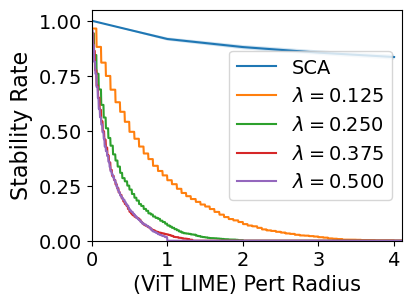

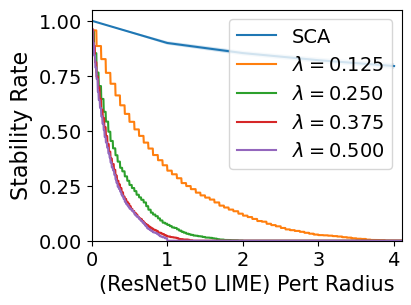

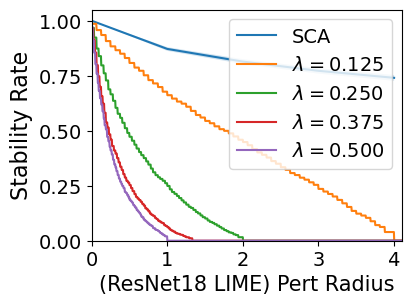

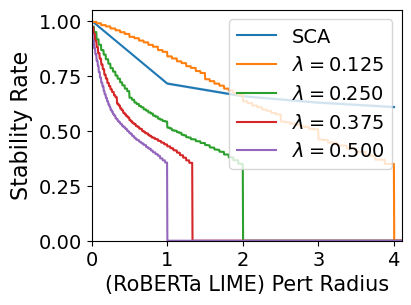

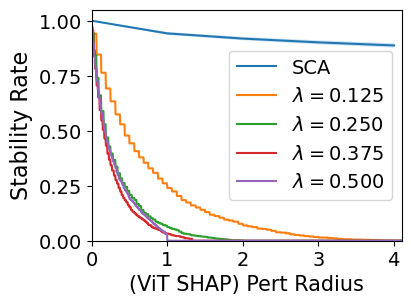

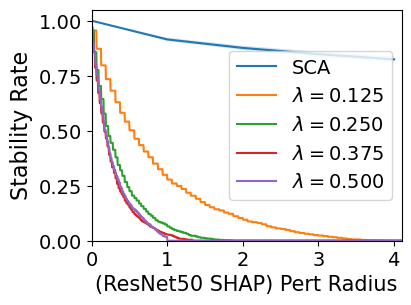

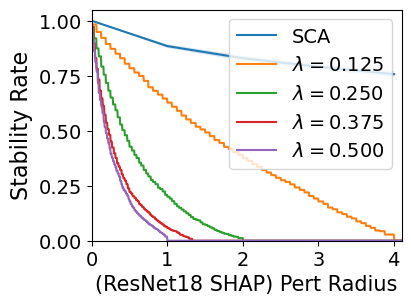

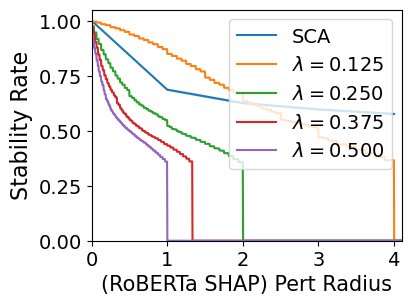

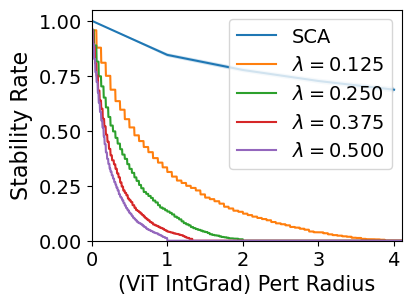

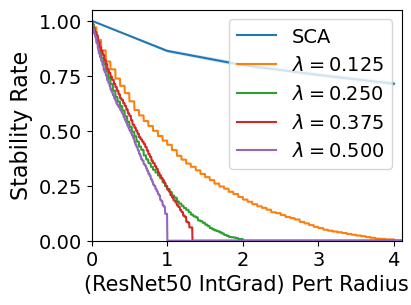

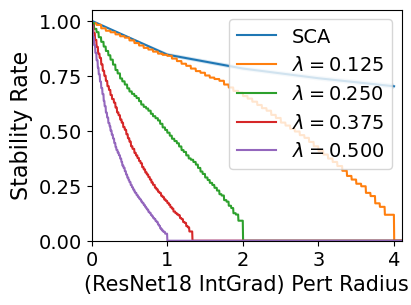

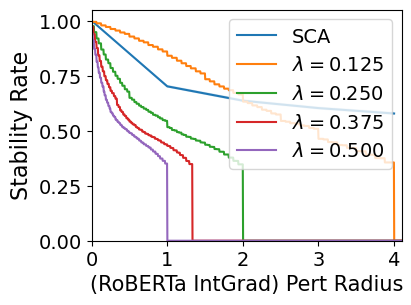

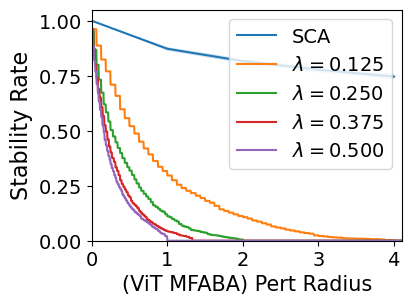

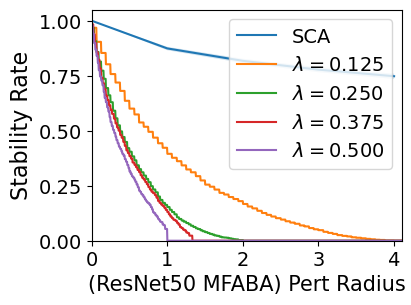

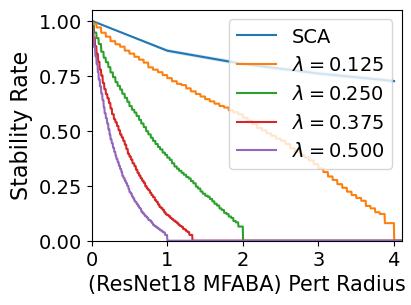

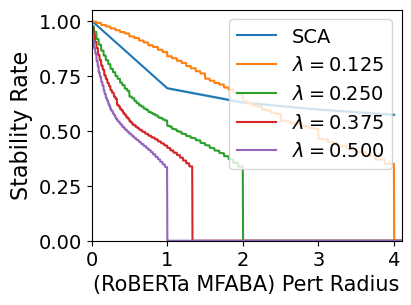

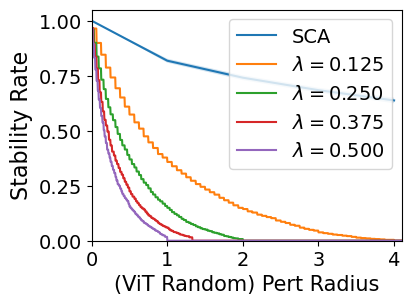

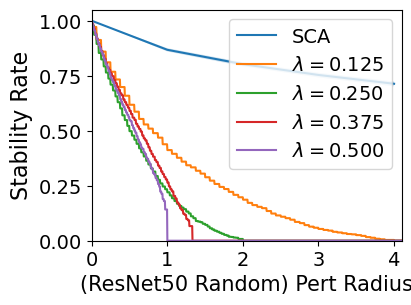

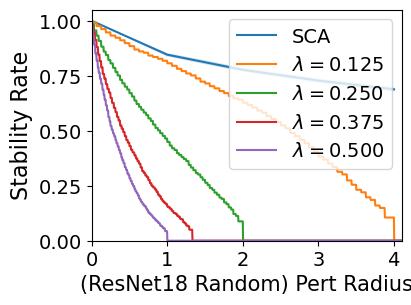

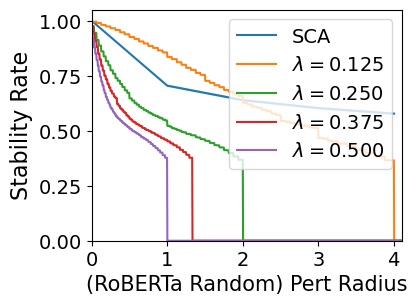

In [9]:
for method in ["LIME", "SHAP", "IntGrad", "MFABA", "Random"]:
    fig = plot_soft_hard_radii_by_method(vit_soft_rates, vit_hard_radii, "ViT", method)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_vit_imagenet_2_per_class_{method.lower()}.pdf", bbox_inches="tight")

    fig = plot_soft_hard_radii_by_method(resnet50_soft_rates, resnet50_hard_radii, "ResNet50", method)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_resnet50_imagenet_2_per_class_{method.lower()}.pdf", bbox_inches="tight")

    fig = plot_soft_hard_radii_by_method(resnet18_soft_rates, resnet18_hard_radii, "ResNet18", method)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_resnet18_imagenet_2_per_class_{method.lower()}.pdf", bbox_inches="tight")

    fig = plot_soft_hard_radii_by_method(roberta_all_soft_rates, roberta_all_hard_radii, "RoBERTa", method)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_roberta_tweeteval_all_{method.lower()}.pdf", bbox_inches="tight")

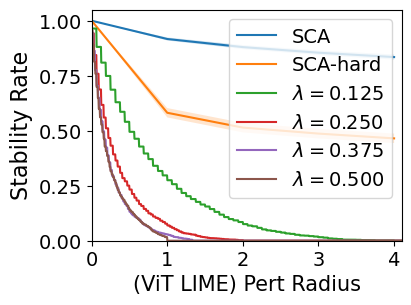

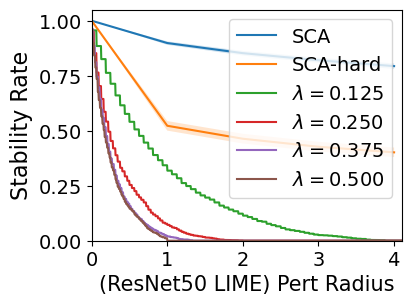

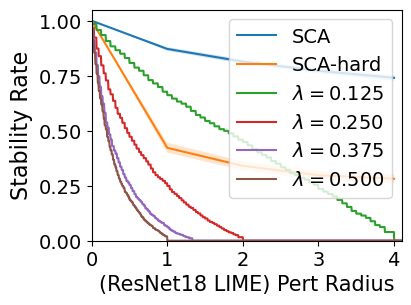

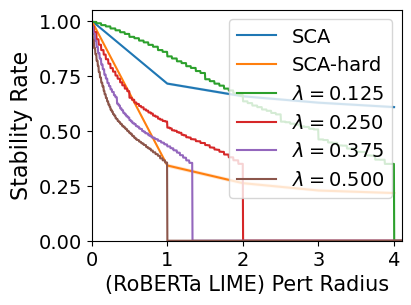

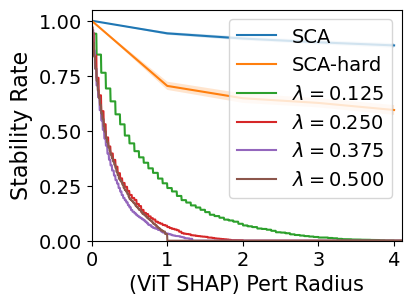

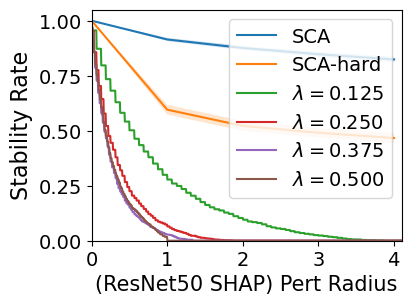

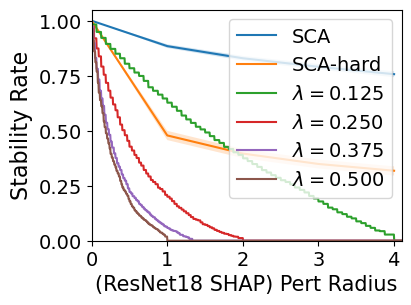

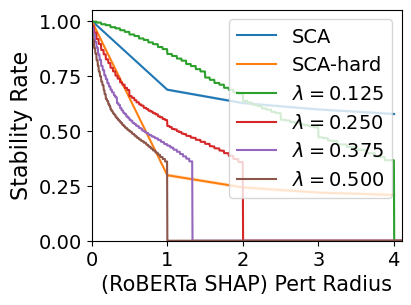

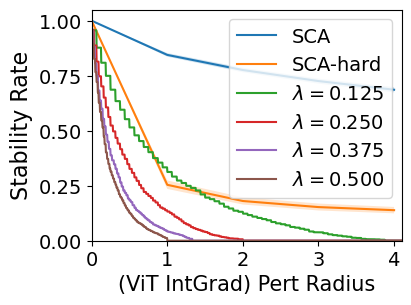

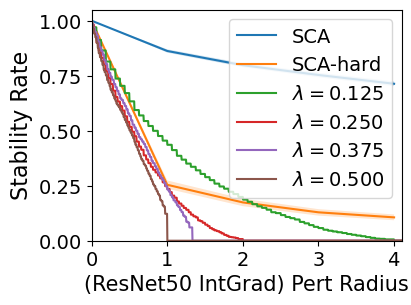

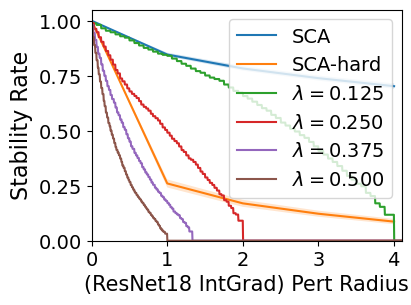

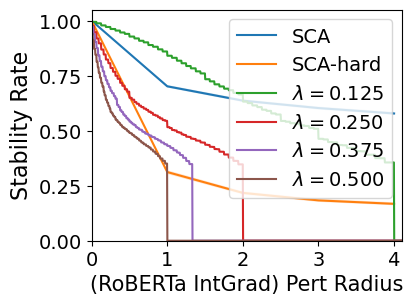

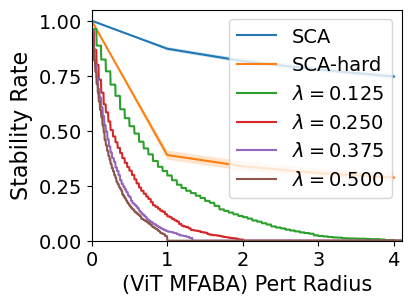

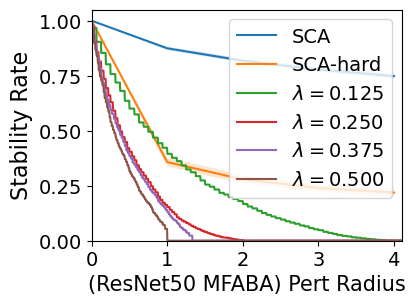

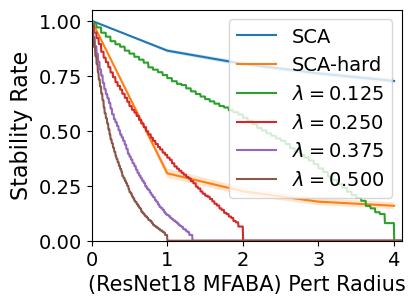

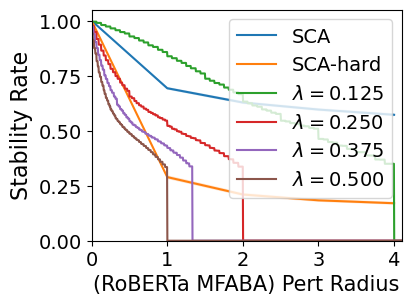

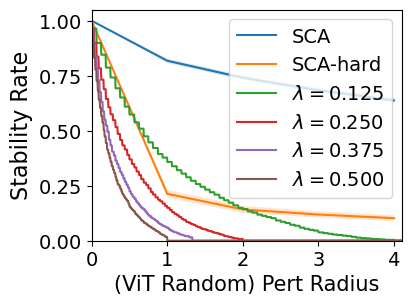

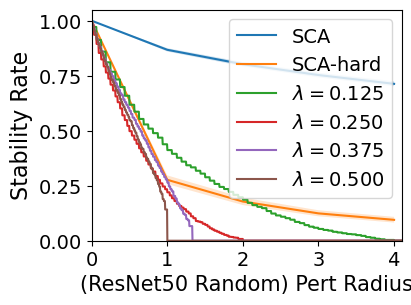

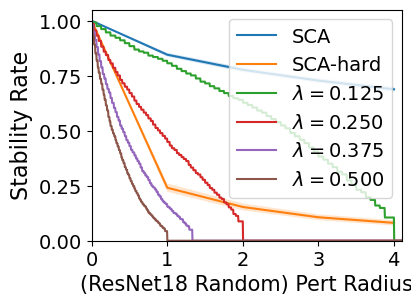

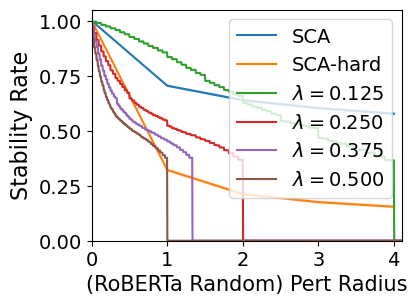

In [10]:
for method in ["LIME", "SHAP", "IntGrad", "MFABA", "Random"]:
    fig = plot_soft_hard_radii_by_method(vit_soft_rates, vit_hard_radii, "ViT", method, est_hard=True)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_est_vit_imagenet_2_per_class_{method.lower()}.pdf", bbox_inches="tight")

    fig = plot_soft_hard_radii_by_method(resnet50_soft_rates, resnet50_hard_radii, "ResNet50", method, est_hard=True)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_est_resnet50_imagenet_2_per_class_{method.lower()}.pdf", bbox_inches="tight")

    fig = plot_soft_hard_radii_by_method(resnet18_soft_rates, resnet18_hard_radii, "ResNet18", method, est_hard=True)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_est_resnet18_imagenet_2_per_class_{method.lower()}.pdf", bbox_inches="tight")

    fig = plot_soft_hard_radii_by_method(roberta_all_soft_rates, roberta_all_hard_radii, "RoBERTa", method, est_hard=True)
    fig.show()
    fig.savefig(f"_dump/soft_vs_hard_est_roberta_tweeteval_all_{method.lower()}.pdf", bbox_inches="tight")

In [11]:
vit_soft_rates

{'lime': array([[1.    , 0.4467, 0.34  , ..., 0.    , 0.    , 0.    ],
        [1.    , 1.    , 1.    , ..., 1.    , 1.    , 1.    ],
        [1.    , 0.7667, 0.7667, ..., 0.    , 0.    , 0.    ],
        ...,
        [1.    , 1.    , 1.    , ..., 1.    , 1.    , 1.    ],
        [1.    , 0.8533, 0.8733, ..., 0.    , 0.    , 0.0067],
        [1.    , 0.8067, 0.7533, ..., 0.    , 0.    , 0.0133]]),
 'shap': array([[1.    , 1.    , 1.    , ..., 1.    , 1.    , 1.    ],
        [1.    , 1.    , 1.    , ..., 1.    , 1.    , 1.    ],
        [1.    , 1.    , 1.    , ..., 0.9   , 0.9267, 0.9333],
        ...,
        [1.    , 1.    , 1.    , ..., 1.    , 1.    , 1.    ],
        [1.    , 0.9333, 0.72  , ..., 0.0467, 0.06  , 0.04  ],
        [1.    , 0.88  , 0.8933, ..., 0.    , 0.    , 0.    ]]),
 'intgrad': array([[1.    , 0.98  , 0.9533, ..., 1.    , 1.    , 1.    ],
        [1.    , 0.8867, 0.8   , ..., 0.    , 0.    , 0.    ],
        [1.    , 0.64  , 0.5067, ..., 0.    , 0.    , 0.    ]

In [12]:
def plot_hard_rates_by_lambda(radii_dict, lambda_: str, title, legend_loc=None, fs=14, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))
    max_radius = 4.0

    r_ticks = np.linspace(0.0, max_radius, num=1000)
    cert_rs = np.array([(radii_dict["lime"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="LIME")

    cert_rs = np.array([(radii_dict["shap"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="SHAP")
    
    cert_rs = np.array([(radii_dict["intgrad"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="IntGrad")

    cert_rs = np.array([(radii_dict["mfaba"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="MFABA")
    
    cert_rs = np.array([(radii_dict["random"][lambda_] >= rt).mean() for rt in r_ticks])
    ax.plot(r_ticks, cert_rs, label="Random")

    ax.set_ylim(0.0, 1.05)
    ax.set_xlabel(f"({title}) Radius", fontsize=fs+2)
    ax.set_ylabel("Stability Rate", fontsize=fs+2)
    ax.tick_params(axis="both", labelsize=fs)

    if xticks is not None:
        ax.set_xticks(xticks)
        ax.set_xlim(0.0, xticks[-1] + 0.05)
    else:
        ax.set_xticks([0, 1, 2, 3, 4])
        ax.set_xlim(0.0, 4.05)

    # ax.legend(title=title, loc=legend_loc, title_fontsize=fs, fontsize=fs-2)
    ax.legend(loc=legend_loc, fontsize=fs)
    return fig

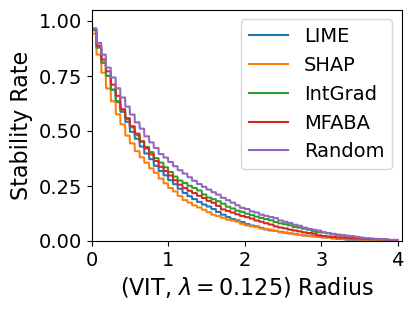

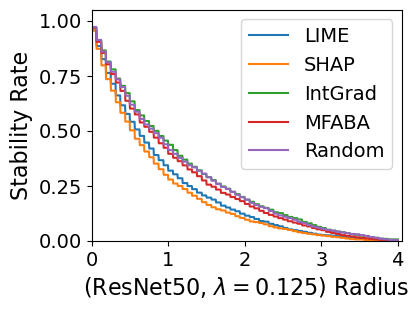

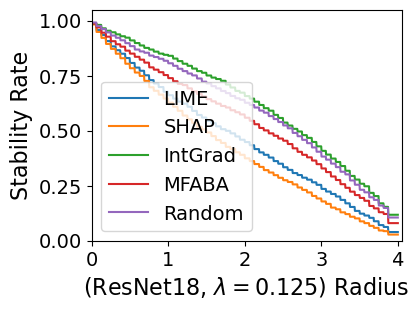

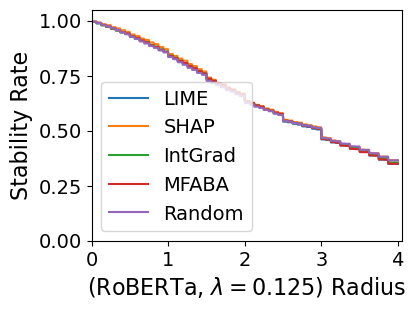

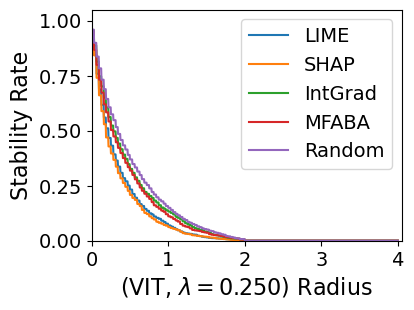

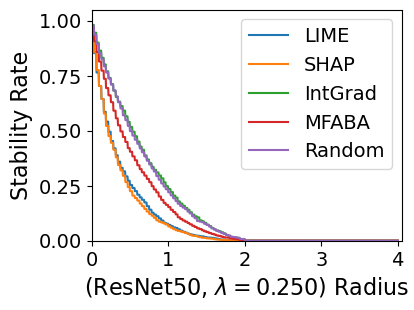

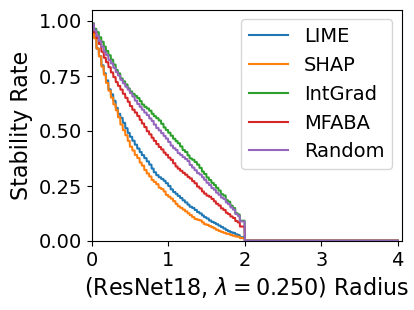

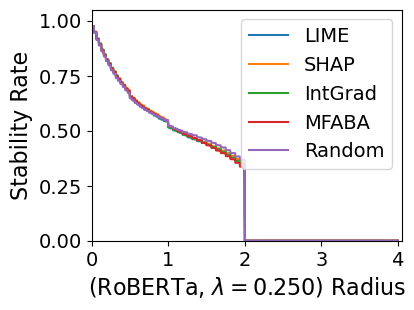

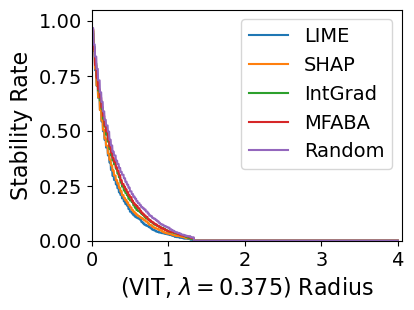

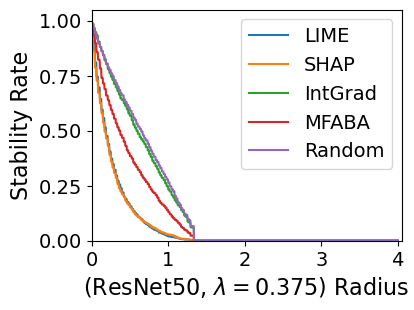

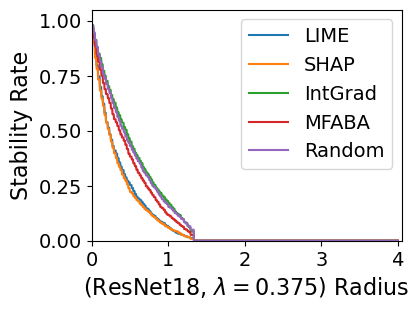

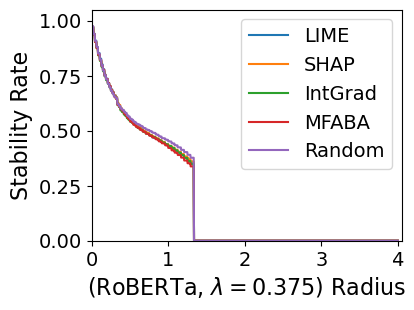

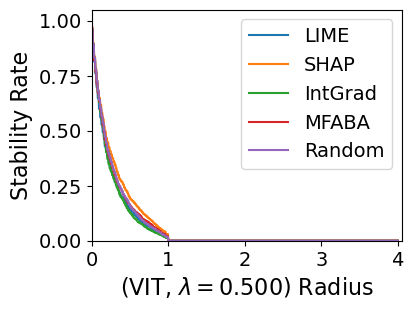

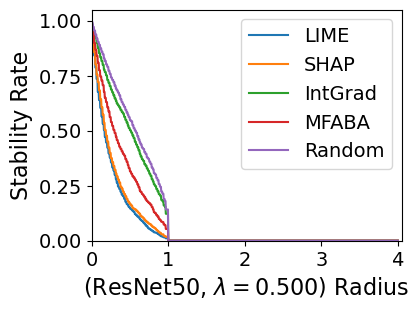

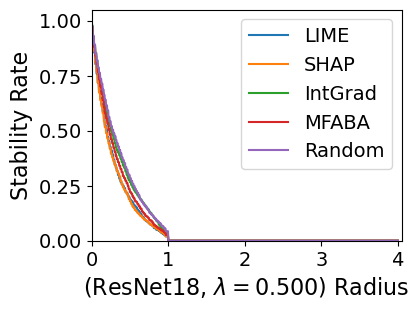

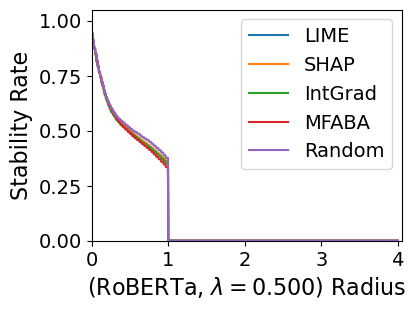

In [13]:
for lambda_ in ["0.125", "0.250", "0.375", "0.500"]:    
    fig = plot_hard_rates_by_lambda(vit_hard_radii, lambda_, f"VIT, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_vit_imagenet_2_per_class_{lambda_}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_lambda(resnet50_hard_radii, lambda_, f"ResNet50, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_resnet50_imagenet_2_per_class_{lambda_}.pdf", bbox_inches="tight")
    
    fig = plot_hard_rates_by_lambda(resnet18_hard_radii, lambda_, f"ResNet18, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_resnet18_imagenet_2_per_class_{lambda_}.pdf", bbox_inches="tight")

    fig = plot_hard_rates_by_lambda(roberta_all_hard_radii, lambda_, f"RoBERTa, $\lambda = {lambda_}$")
    fig.show()
    fig.savefig(f"_dump/hard_vs_lambda_roberta_tweeteval_all_{lambda_}.pdf", bbox_inches="tight")

In [14]:
def plot_hard_rates_sca_soft(model_rates, model, legend_loc=None, fs=14, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))
    r_max = 4
    radii = list(range(0, r_max+1))

    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["lime"][:, :r_max+1])
    ax.plot(radii, mean, label="LIME")
    ax.fill_between(radii, lb, ub, alpha=0.2)
    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["shap"][:, :r_max+1])
    ax.plot(radii, mean, label="SHAP")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["intgrad"][:, :r_max+1])
    ax.plot(radii, mean, label="IntGrad")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["mfaba"][:, :r_max+1])
    ax.plot(radii, mean, label="MFABA")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    
    mean, lb, ub = bootstrap_mean_and_ci(model_rates["random"][:, :r_max+1])
    ax.plot(radii, mean, label="Random")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    ax.set_xlabel(f"({model}, SCA) Radius", fontsize=fs+2)
    ax.set_ylabel("Stability Rate", fontsize=fs+2)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(loc=legend_loc, title_fontsize=fs, fontsize=fs)
    return fig


def plot_hard_rates_sca_hard(model_rates, model, legend_loc=None, fs=14, xticks=None):
    fig, ax = plt.subplots(figsize=(4,3))
    r_max = 4
    radii = list(range(0, r_max+1))

    est_hards = (model_rates["lime"] > 0.999).astype(float)[:, :r_max+1]
    mean, lb, ub = bootstrap_mean_and_ci(est_hards)
    ax.plot(radii, mean, label="LIME")
    ax.fill_between(radii, lb, ub, alpha=0.2)
    
    est_hards = (model_rates["shap"] > 0.999).astype(float)[:, :r_max+1]
    mean, lb, ub = bootstrap_mean_and_ci(est_hards)
    ax.plot(radii, mean, label="SHAP")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    est_hards = (model_rates["intgrad"] > 0.999).astype(float)[:, :r_max+1]
    mean, lb, ub = bootstrap_mean_and_ci(est_hards)
    ax.plot(radii, mean, label="IntGrad")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    est_hards = (model_rates["mfaba"] > 0.999).astype(float)[:, :r_max+1]
    mean, lb, ub = bootstrap_mean_and_ci(est_hards)
    ax.plot(radii, mean, label="MFABA")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    est_hards = (model_rates["random"] > 0.999).astype(float)[:, :r_max+1]
    mean, lb, ub = bootstrap_mean_and_ci(est_hards)
    ax.plot(radii, mean, label="Random")
    ax.fill_between(radii, lb, ub, alpha=0.2)

    ax.set_xlabel(f"({model}, SCA-hard) Radius", fontsize=fs+2)
    ax.set_ylabel("Stability Rate", fontsize=fs+2)
    ax.tick_params(axis="both", labelsize=fs)
    if xticks is not None:
        ax.set_xticks(xticks)
    ax.legend(loc=legend_loc, title_fontsize=fs, fontsize=fs)
    return fig

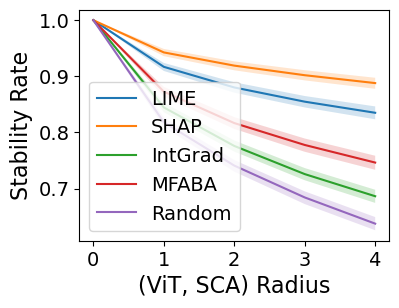

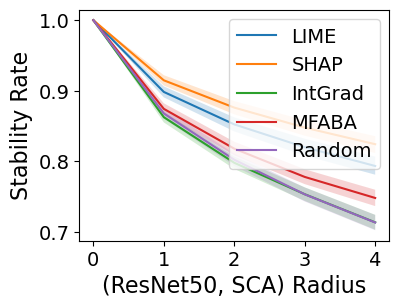

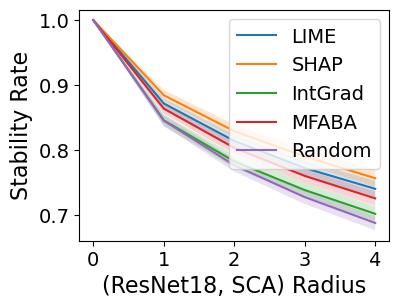

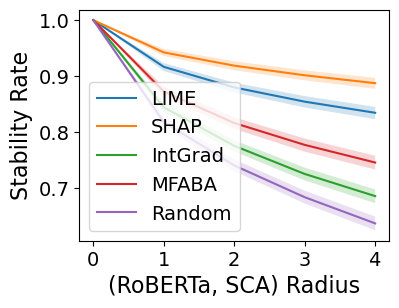

In [15]:
fig = plot_hard_rates_sca_soft(vit_soft_rates, "ViT")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_vit_imagenet_2_per_class_sca.pdf", bbox_inches="tight")

fig = plot_hard_rates_sca_soft(resnet50_soft_rates, "ResNet50")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_resnet50_imagenet_2_per_class_sca.pdf", bbox_inches="tight")

fig = plot_hard_rates_sca_soft(resnet18_soft_rates, "ResNet18")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_resnet18_imagenet_2_per_class_sca.pdf", bbox_inches="tight")

fig = plot_hard_rates_sca_soft(vit_soft_rates, "RoBERTa")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_roberta_tweeteval_all_sca.pdf", bbox_inches="tight")

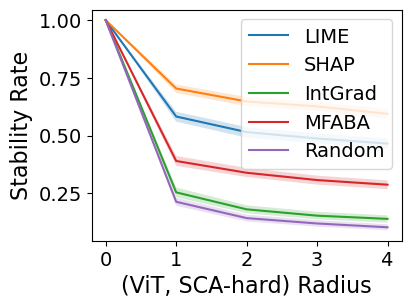

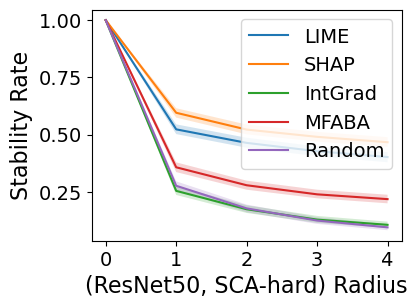

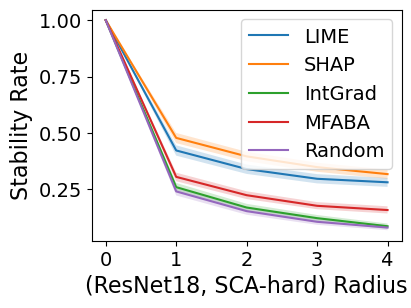

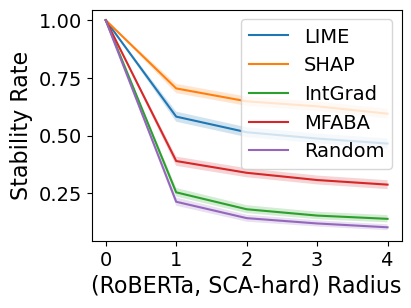

In [16]:
fig = plot_hard_rates_sca_hard(vit_soft_rates, "ViT")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_vit_imagenet_2_per_class_scahard.pdf", bbox_inches="tight")

fig = plot_hard_rates_sca_hard(resnet50_soft_rates, "ResNet50")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_resnet50_imagenet_2_per_class_scahard.pdf", bbox_inches="tight")

fig = plot_hard_rates_sca_hard(resnet18_soft_rates, "ResNet18")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_resnet18_imagenet_2_per_class_scahard.pdf", bbox_inches="tight")

fig = plot_hard_rates_sca_hard(vit_soft_rates, "RoBERTa")
fig.show()
fig.savefig(f"_dump/hard_vs_lambda_roberta_tweeteval_all_scahard.pdf", bbox_inches="tight")